<a href="https://colab.research.google.com/github/anuragpatil811/Machine-Learning/blob/main/Diabetes_Prediction_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [4]:
df = pd.read_csv('/content/diabetes.csv')
df.head(3)

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1


In [5]:
df.isnull().sum()

,0
glucose,0
bloodpressure,0
diabetes,0


In [6]:
df.duplicated().sum()

np.int64(820)

In [7]:
df.drop_duplicates(inplace=True)

<Axes: ylabel='bloodpressure'>

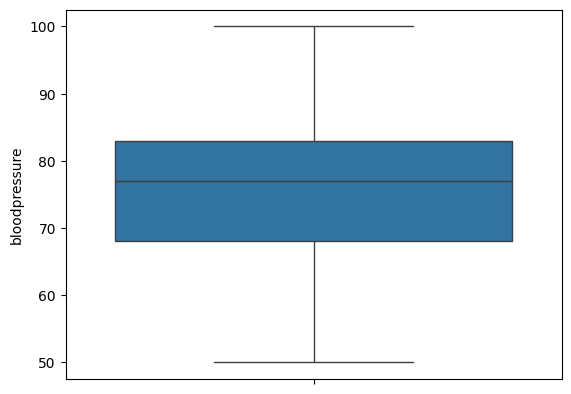

In [10]:
sns.boxplot(data=df, y="bloodpressure")

In [11]:
df["glucose"].describe()

,glucose
count,175.000000
mean,44.485714
std,10.367864
min,20.000000
25%,40.000000
50%,45.000000
75%,50.000000
max,70.000000


In [12]:
q1 = 40.0
q3 = 50.0

In [13]:
IQR = q3 - q1

In [14]:
ub = q3 + 1.5*IQR
lb = q1 - 1.5*IQR

In [15]:
df = df[(df["glucose"]>lb)&(df["glucose"]<ub)]

<Axes: ylabel='glucose'>

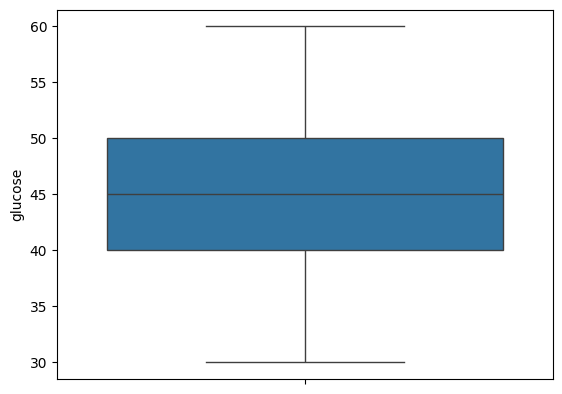

In [16]:
sns.boxplot(data=df, y="glucose")

In [17]:
x = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.neighbors import KNeighborsClassifier

In [21]:
model = KNeighborsClassifier(n_neighbors=3)

In [22]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [23]:
y_predict = model.predict(X_test)

In [24]:
#Training Score
model.score(X_train, y_train)

0.8467741935483871

In [25]:
#Testing Score
model.score(X_test, y_test)

0.8125

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_predict)
cr = classification_report(y_test, y_predict)

In [28]:
print(cr)

              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.86      0.86      0.86        22

    accuracy                           0.81        32
   macro avg       0.78      0.78      0.78        32
weighted avg       0.81      0.81      0.81        32



<Axes: >

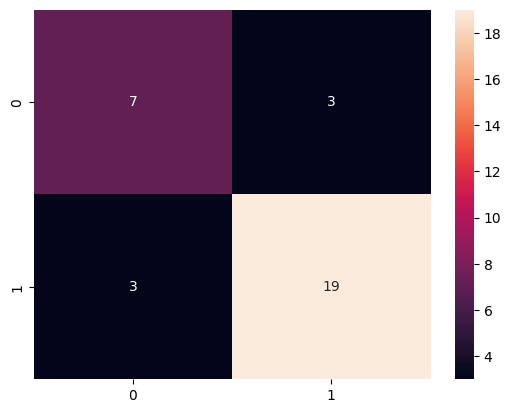

In [30]:
sns.heatmap(cm, annot=True)